# Mapas de tendencias significativas: proyecciones climáticas por punto de grilla

**Geocomputación (1GEO20)** — PUCP, 2026-II — Semana 7


En este notebook calculamos la tendencia (Mann-Kendall + pendiente de Sen) en cada punto de grilla de una región, comparando el periodo histórico (1950-2014) con el periodo futuro (2015-2099) bajo un escenario, y la graficamos como un mapa marcando qué zonas son estadísticamente significativas.

**Datos:** [NASA NEX-GDDP-CMIP6](https://developers.google.com/earth-engine/datasets/catalog/NASA_GDDP-CMIP6), variable `pr`, recortados a la región Lon(-85, -65) / Lat(-20, 5). 2 modelos (ACCESS-CM2, CMCC-ESM2), histórico (1950-2014) y 2 escenarios (SSP2-4.5, SSP5-8.5) hasta 2099, resolución mensual.


## 0. Descargar los datos

In [ ]:
# Alternativa para descargar la carpeta compartida de Google Drive
# Descomenta y reemplaza el ID por el de la carpeta compartida

# !pip install gdown -q
# import gdown
# gdown.download_folder(id="1ZP-yqBKVZ8bYkbnxJL_hQpxl0qz9MP-6", output="datos_proyecciones", quiet=False)

Retrieving folder contents


Retrieving folder 1QwR9SnzDrOtFPhrbjmixte73DtF2onh0 pr
Retrieving folder 1udLNYN2s1MBF9essbIf4b6mBO25nyc02 ACCESS-CM2
Processing file 1eX5jBhba3YqY-_PplFC7JKAgdd31RcSa pr_ACCESS-CM2_1950-2014_historical.nc
Processing file 1O_LWVS34T2RY3f3Lj37on0bPXnMrwfOn pr_ACCESS-CM2_2015-2049_ssp245.nc
Processing file 1Iu6XcPRBvvR1P8DT_t11ru8PmrYZyBnS pr_ACCESS-CM2_2015-2049_ssp585.nc
Processing file 1EYoHZwjKP2DGcSlcWxX1gWDbCiJSCQM3 pr_ACCESS-CM2_2050-2099_ssp245.nc
Processing file 1mzvZ5zcyVubraTLiQBMoCcBWmAMaIgrn pr_ACCESS-CM2_2050-2099_ssp585.nc
Retrieving folder 1gULI7KQN6xuK3L7L4uQk0HXZft-W8_9F CMCC-ESM2
Processing file 1JMacFqdpw4wAwcklf4dgkfOFy9gZDqoP pr_CMCC-ESM2_1950-2014_historical.nc
Processing file 12tpPIpevwxFnbU70k_XHg8NLNPxNf__U pr_CMCC-ESM2_2015-2049_ssp245.nc
Processing file 1IcowaX2lxWnuP-uVC7PVqye2vOeLq2jC pr_CMCC-ESM2_2015-2049_ssp585.nc
Processing file 1HOlAHVZy6TTFDQLsUAwj_F3HhE3ccg1X pr_CMCC-ESM2_2050-2099_ssp245.nc
Processing file 12G1IQX4k6ASVGrbGCDxOEG6kM4Cet3px pr_CMCC-ES

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1eX5jBhba3YqY-_PplFC7JKAgdd31RcSa
To: c:\Users\sebas\OneDrive\Documentos\GitHub\geocomputacion\geocomputacion_-1GEO20-\ejercicios\ejercicios_aplicados\datos_proyecciones\pr\ACCESS-CM2\pr_ACCESS-CM2_1950-2014_historical.nc
100%|██████████| 25.0M/25.0M [00:01<00:00, 17.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1O_LWVS34T2RY3f3Lj37on0bPXnMrwfOn
To: c:\Users\sebas\OneDrive\Documentos\GitHub\geocomputacion\geocomputacion_-1GEO20-\ejercicios\ejercicios_aplicados\datos_proyecciones\pr\ACCESS-CM2\pr_ACCESS-CM2_2015-2049_ssp245.nc
100%|██████████| 13.5M/13.5M [00:00<00:00, 14.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Iu6XcPRBvvR1P8DT_t11ru8PmrYZyBnS
To: c:\Users\sebas\OneDrive\Documentos\GitHub\geocomputacion\geocomputacion_-1GEO20-\ejercicios\ejercicios_aplicados\datos_proyecciones\pr\ACCESS-CM2\pr_ACCESS

['datos_proyecciones\\pr\\ACCESS-CM2\\pr_ACCESS-CM2_1950-2014_historical.nc',
 'datos_proyecciones\\pr\\ACCESS-CM2\\pr_ACCESS-CM2_2015-2049_ssp245.nc',
 'datos_proyecciones\\pr\\ACCESS-CM2\\pr_ACCESS-CM2_2015-2049_ssp585.nc',
 'datos_proyecciones\\pr\\ACCESS-CM2\\pr_ACCESS-CM2_2050-2099_ssp245.nc',
 'datos_proyecciones\\pr\\ACCESS-CM2\\pr_ACCESS-CM2_2050-2099_ssp585.nc',
 'datos_proyecciones\\pr\\CMCC-ESM2\\pr_CMCC-ESM2_1950-2014_historical.nc',
 'datos_proyecciones\\pr\\CMCC-ESM2\\pr_CMCC-ESM2_2015-2049_ssp245.nc',
 'datos_proyecciones\\pr\\CMCC-ESM2\\pr_CMCC-ESM2_2015-2049_ssp585.nc',
 'datos_proyecciones\\pr\\CMCC-ESM2\\pr_CMCC-ESM2_2050-2099_ssp245.nc',
 'datos_proyecciones\\pr\\CMCC-ESM2\\pr_CMCC-ESM2_2050-2099_ssp585.nc',
 'datos_proyecciones\\pr\\IPSL-CM6A-LR\\pr_IPSL-CM6A-LR_1950-2014_historical.nc',
 'datos_proyecciones\\pr\\IPSL-CM6A-LR\\pr_IPSL-CM6A-LR_2015-2049_ssp245.nc',
 'datos_proyecciones\\pr\\IPSL-CM6A-LR\\pr_IPSL-CM6A-LR_2015-2049_ssp585.nc',
 'datos_proyecciones\\pr

In [ ]:
# # o en Colab
# Descomenta y reemplaza el ID por el de la carpeta compartida
# !gdown --folder "1ZP-yqBKVZ8bYkbnxJL_hQpxl0qz9MP-6" -O datos_proyecciones
# !pip install cartopy -q

## 1. Importar librerías

In [24]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.stats import kendalltau, theilslopes

## 2. Cargar los datos

Misma estructura de carpetas que en `proyecciones_climaticas_grillado.ipynb`:

```
datos_proyecciones/{variable}
├── ACCESS-CM2/
│   ├── {variable}_ACCESS-CM2_1950-2014_historical.nc
│   ├── {variable}_ACCESS-CM2_2015-2049_ssp245.nc
│   ├── {variable}_ACCESS-CM2_2050-2099_ssp245.nc
│   ├── {variable}_ACCESS-CM2_2015-2049_ssp585.nc
│   └── {variable}_ACCESS-CM2_2050-2099_ssp585.nc
└── CMCC-ESM2/
    └── ... (misma estructura)
```

Donde `variable` puede ser `tasmax` o `pr` 

In [ ]:
# Se definen las variables para la asignación de direcciones
variable = "pr"  # pr: precipitación; cambiar a "tasmax" para trabajar con la otra variable
carpeta_datos = "datos_proyecciones/"+variable+"/"

modelos = ["ACCESS-CM2", "CMCC-ESM2", "MPI-ESM1-2-LR", "NorESM2-LM", "IPSL-CM6A-LR"]
escenarios = ["ssp245", "ssp585"]  # tal cual aparecen en los nombres de archivo

In [23]:
# Muy engorroso definirlo a cada rato, se puede definir una vez y guardar en un archivo .py

def cargar_historico(modelo, carpeta, variable):
    ruta = carpeta + modelo + f"/{variable}_{modelo}_1950-2014_historical.nc"
    return xr.open_dataset(ruta)[variable]

def cargar_escenario(modelo, escenario, carpeta, variable):
    carpeta_modelo = carpeta + modelo + "/"
    tramo1 = xr.open_dataset(carpeta_modelo + f"{variable}_{modelo}_2015-2049_{escenario}.nc")[variable]
    tramo2 = xr.open_dataset(carpeta_modelo + f"{variable}_{modelo}_2050-2099_{escenario}.nc")[variable]
    return xr.concat([tramo1, tramo2], dim="time")

# Se llaman a las funciones definidas en el archivo funciones.py
#import funciones as fu

In [25]:
da_por_modelo = []
for modelo in modelos:
    historico = cargar_historico(modelo, carpeta_datos, variable)
    da_por_escenario = []
    for escenario in escenarios:
        futuro = cargar_escenario(modelo, escenario, carpeta_datos, variable)
        da_por_escenario.append(xr.concat([historico, futuro], dim="time"))
    serie_modelo = xr.concat(da_por_escenario, dim="escenario")
    serie_modelo = serie_modelo.assign_coords(escenario=escenarios)
    da_por_modelo.append(serie_modelo)

datos_completo = xr.concat(da_por_modelo, dim="modelo")
datos_completo = datos_completo.assign_coords(modelo=modelos)

## 3. De mensual a anual, sin promediar el espacio

In [ ]:
# En el anterior notebook se hizo .mean("time"), como se está trabajano precipitación, mejor recopilar la precipitación anual con una suma que con un promedio
anual = datos_completo.groupby("time.year").sum("time")  # cambiar a .sum("time") si se prefiere el total anual (para "pr")

## 4. Tendencia por punto de grilla (loop simple)

Mismo test que en `proyecciones_climaticas_grillado.ipynb` (`kendalltau` para significancia, `theilslopes` para la magnitud), aplicado punto por punto. Con series anuales el loop es rápido incluso para toda la grilla.

In [ ]:
def tendencia_por_punto(da_anual):
    years = da_anual["year"].values
    valores = da_anual.values
    ny, nx = valores.shape[1], valores.shape[2] # Esta función está definida para arrays donde las dimensiones [1] y [2] son 'y' y 'x' respectivamente
    pendiente = np.full((ny, nx), np.nan) # Se define un array de dimensiones ny,nx espaciales y se llenan los valores con np.nan
    p_valor = np.full((ny, nx), np.nan)

    for j in range(ny):
        for i in range(nx):
            serie = valores[:, j, i] # serie: todos los valores pertenecientes a una coordenada
            if np.all(np.isnan(serie)): # Define la condición: si todos los valores en un punto son nulos, se salta las instrucciones de cálculo y reinicia la iteración
                continue
            tau, p_valor_ij = kendalltau(years, serie)
            pendiente_ij, intercepto, ic_bajo, ic_alto = theilslopes(serie, years, alpha=0.95)
            pendiente[j, i] = pendiente_ij # Se van asignando los valores de p_valor y tau calculados a sus coordenadas correspondientes
            p_valor[j, i] = p_valor_ij

    coords = {"y": da_anual["y"], "x": da_anual["x"]}
    # Se define el array final con los valores asignados por la iteración en las coordenadas definidas. Adenás, se crea una nueva dimensión para cada coordenada
    pendiente_da = xr.DataArray(pendiente, coords=coords, dims=("y", "x")) 
    p_valor_da = xr.DataArray(p_valor, coords=coords, dims=("y", "x"))
    return pendiente_da, p_valor_da # Devuelve los arrays con la pendiente y el p_valor de cada pixel analizado para cada valor anual dentro de un píxel

In [39]:
# Shape del array objetivo/ideal para la función anterior (year, y, x)
anual.sel(modelo="CMCC-ESM2", escenario="ssp585", year=slice(1950,2014)).shape

(65, 100, 80)

### Aplicamos a un modelo y escenario, histórico vs. futuro

In [42]:
modelo_sel = "CMCC-ESM2"
escenario_sel = "ssp585"

anual_sel = anual.sel(modelo=modelo_sel, escenario=escenario_sel)
anual_historico = anual_sel.sel(year=slice(1950, 2014))
anual_futuro = anual_sel.sel(year=slice(2015, 2099))

pendiente_hist, p_valor_hist = tendencia_por_punto(anual_historico)
pendiente_fut, p_valor_fut = tendencia_por_punto(anual_futuro)

## 5. Mapa de tendencias

Graficamos la pendiente (por año) como mapa, y marcamos con puntos los píxeles donde la tendencia **no** es significativa (p ≥ 0.05). Sin regiones fijas: que ellos interpreten visualmente qué patrones aparecen (costa, Andes, Amazonía) y cómo cambian entre histórico y futuro.

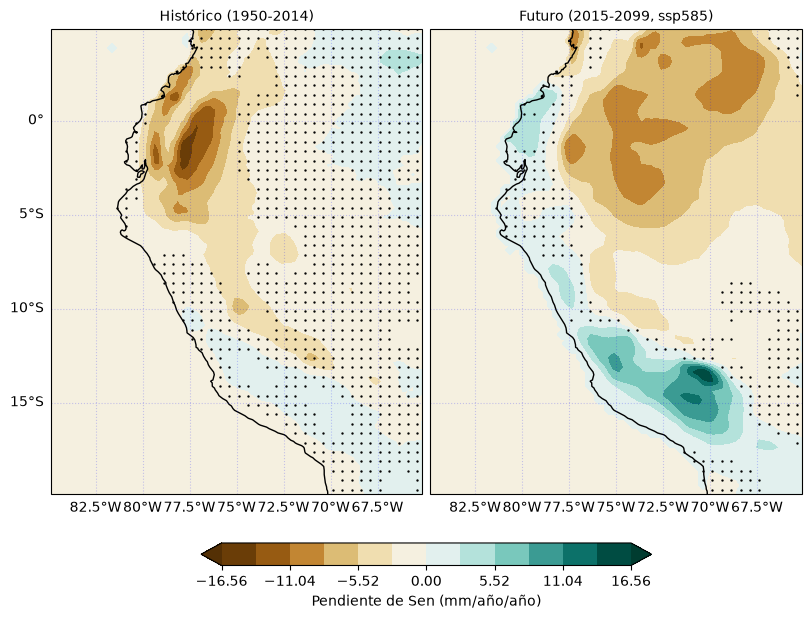

In [ ]:
etiqueta_variable = {"tasmax": "Temperatura máxima", "pr": "Precipitación"}
cmap_variable = {"tasmax": "RdBu_r", "pr": "BrBG"}
# (mm/año si se usa el total anual de pr, o °C si usas tasmax)
unidad_variable = "mm/año"  # cambiar según variable y agregación elegida

max_abs = float(max(np.nanmax(np.abs(pendiente_hist)), np.nanmax(np.abs(pendiente_fut)))) # Extrae el valor máximo absoluto entre la pendiente histórica y la futura
niveles = np.linspace(-max_abs, max_abs, 13) # Define la extensión de la paleta de colores en el rango máximo, dividiéndolo en 13 partes de igual rango

X, Y = np.meshgrid(pendiente_hist["x"], pendiente_hist["y"]) # Define 2 tuplas de matrices de coordenadas 'x' y 'y'

fig, axs = plt.subplots(1, 2, figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True)

for ax, pendiente_periodo, p_valor_periodo, titulo in zip(
    axs, [pendiente_hist, pendiente_fut], [p_valor_hist, p_valor_fut],
    ["Histórico (1950-2014)", f"Futuro (2015-2099, {escenario_sel})"]):

    cf = ax.contourf(pendiente_periodo["x"], pendiente_periodo["y"], pendiente_periodo,
                      levels=niveles, cmap=cmap_variable[variable], extend="both",
                      transform=ccrs.PlateCarree())

    mascara_no_sig = (p_valor_periodo >= 0.05).values
    # si el mapa queda muy saturado de puntos, prueba con un subsampleo:
    # X[::2, ::2], Y[::2, ::2], mascara_no_sig[::2, ::2]
    ax.scatter(X[::2, ::2][mascara_no_sig[::2, ::2]], Y[::2, ::2][mascara_no_sig[::2, ::2]], s=2, color="k", marker=".",
               transform=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=False, color='b', alpha = 0.2, linestyle=':')
    gl.left_labels = True
    gl.bottom_labels = True

    ax.coastlines()
    ax.set_title(titulo, fontsize=10)
gl.left_labels = (ax == axs[0])  # Only show left labels for the first subplot

# fig.suptitle(f"Tendencia de {etiqueta_variable[variable]} — {modelo_sel}")
fig.colorbar(cf, ax=axs, orientation="horizontal", shrink=0.6,
             label=f"Pendiente de Sen ({unidad_variable}/año)")
plt.show()

## Bonus: versión vectorizada con `xr.apply_ufunc`

Una forma más eficiente en xarray es usar `xr.apply_ufunc`, que aplica una función 1D a lo largo de una dimensión (aquí, `"year"`) sobre todos los puntos de grilla a la vez, sin escribir el loop explícito. 

In [18]:
years_futuro = anual_futuro["year"].values


def _tendencia_1d(serie, years=years_futuro):
    if np.all(np.isnan(serie)):
        return np.nan, np.nan
    tau, p_valor_ij = kendalltau(years, serie)
    pendiente_ij, intercepto, ic_bajo, ic_alto = theilslopes(serie, years, alpha=0.95)
    return pendiente_ij, p_valor_ij


pendiente_fut_vec, p_valor_fut_vec = xr.apply_ufunc(
    _tendencia_1d, anual_futuro,
    input_core_dims=[["year"]],
    output_core_dims=[[], []],
    vectorize=True,
    output_dtypes=[float, float],
)

In [20]:
# comprobación: debería dar True en ambos casos
# np.allclose(a, b) devuelve True si todos los elementos de a y b son iguales dentro de una tolerancia muy pequeña
# equal_nan=True hace que dos NaN en la misma posición cuenten como iguales
print(np.allclose(pendiente_fut.values, pendiente_fut_vec.values, equal_nan=True))
print(np.allclose(p_valor_fut.values, p_valor_fut_vec.values, equal_nan=True))

True
True
